# Donation-Intent Classifier Training — v14-Antiphony: Dual-Stream Persuader/Persuadee Cross-Attention

A genuinely new architecture, not an increment of v6's hierarchical
encoder. Binary-only from the start (same teacher-directed focus as
`capstone-v13-solo.ipynb`, which this forks for everything except the
model class itself — data loading, augmentation, loss, and the training
loop are v13-Solo's, unchanged, so any difference in the numbers is
attributable to the architecture alone).

---

## The idea

Every notebook so far (v3-v13) encodes a dialogue as **one interleaved
sequence of turns**, with speaker role injected only as an additive
embedding on top of an otherwise role-blind attention pass. That throws
away a structural fact this whole task is built on: persuasion dialogues
have two **asymmetric** roles — one party argues, the other decides —
and the label is defined entirely by what the deciding party (the
Persuadee) does. Modeling both parties as one undifferentiated sequence
means the architecture has to *rediscover* who's who from a role
embedding alone.

**v14-Antiphony instead treats the dialogue as two related but distinct
streams from the start:**

1. **Speaker-disentangled discourse encoding.** After the same shared
   per-turn utterance encoding used everywhere in this project
   (unchanged — that part is proven), turn vectors are split by role
   into a Persuader stream and a Persuadee stream, each in its own
   chronological order, and each given its **own** small Transformer
   (`persuader_transformer` / `persuadee_transformer`, 2 layers each).
   This models how each party's *own* argument or stance develops across
   *their own* turns — intra-speaker discourse coherence a single mixed
   sequence can't cleanly separate. (Same family of idea as
   *DialogueRNN*'s per-party state tracking, Majumder et al., AAAI 2019
   — built there for emotion recognition in conversation, adapted here
   for persuasion outcome.)

2. **Directional cross-attention.** The Persuadee stream **queries** the
   Persuader stream (`nn.MultiheadAttention`, Persuadee as query,
   Persuader as key/value) — an explicit, asymmetric "how does the
   decision-maker's stance respond to what was argued" mechanism, rather
   than a symmetric self-attention pass that treats both roles
   interchangeably. "Antiphony" names this: alternating call-and-
   response between two distinct voices, which is structurally what a
   persuasion dialogue actually is.

3. **Commitment-trajectory head.** A `nn.GRU` runs over the cross-
   attended Persuadee stream in chronological order; its **final**
   hidden state is a "how did commitment build up, turn by turn" signal
   — a genuinely different mechanism from every prior notebook's
   attention-pooled *snapshot* of the whole dialogue. It's concatenated
   with an attention-pooled summary of the same stream (kept, for the
   "what mattered most overall" signal attention pooling already gives)
   before the binary head.

No `recency_strength` scalar, no hand-tuned recency bias (v10-Coda's
mechanism) — a GRU's hidden state is *inherently* more shaped by recent
inputs, so sequential recency emerges from the trajectory head's own
inductive bias instead of being hand-coded in.

## Why this counts as a new architecture, not a variant

Every other notebook shares one skeleton: shared utterance encoder ->
role+position embeddings -> one dialogue-level Transformer over the
interleaved sequence -> attention pooling (± gating/recency) -> head(s).
v14-Antiphony changes what happens *after* the shared utterance encoder
entirely: two role-pure streams, two separate Transformers, one
directional cross-attention layer, and a recurrent trajectory head
replace the single dialogue Transformer + attention-pool + gate. Nothing
downstream of `_encode_turns()` is shared with v6-v13.

## Implementation notes

- `_split_by_role()` re-packs the `[B, U, H]` turn-vector tensor (already
  computed by the unchanged shared encoder) into two `[B,
  max_role_len, H]` tensors, one per role, keeping each role's **last**
  `max_role_len` real turns in original order (same "preserve the
  closing turns under truncation" convention used everywhere else in
  this project). `max_role_len=20` gives full headroom — the corpus's
  own turn-count distribution (p95=23 total turns/dialogue) means either
  role alone essentially never approaches 20.
- Padding is handled the same way throughout as elsewhere in this
  project: `key_padding_mask` (`True` = ignore) for both per-stream
  Transformers and the cross-attention layer, and `pack_padded_sequence`
  (via each row's true per-role turn count) for the GRU, so the
  trajectory head's final hidden state is read at each dialogue's real
  last Persuadee turn, never a padding slot.
- The shared per-turn utterance encoder is untouched, including its
  gradient checkpointing — the OOM-safety fix carries over unchanged,
  and this architecture doesn't add another transformer over the full
  `[B*U, L]` flattened batch, only two much shorter (`R<=20` vs `U<=32`)
  Transformers over already-pooled turn vectors, so it should be
  *lighter* on memory than v6-v13's single 4-layer dialogue Transformer,
  not heavier.

## Avoiding past mistakes

| Past mistake | Why it doesn't recur here |
|---|---|
| DeBERTa-v3 OOM | Same fix carried over unchanged. The new stream Transformers/cross-attention/GRU operate on pooled `[B, R<=20, H]` tensors, far smaller than the `[B*U, L]` flattened tensors the utterance encoder itself handles — no new OOM surface. |
| 5+ hour runtime (v8) | Same augmentation and training loop as v13-Solo (~2-3 hr territory). Two 2-layer stream Transformers over R<=20 turns are cheaper than one 4-layer Transformer over U<=32 turns. |

## What to check in the results

- Does this beat v13-Solo's own per-encoder binary macro-F1 numbers —
  i.e. does explicit role-disentanglement + directional cross-attention
  + trajectory modeling beat the single-sequence-plus-gating approach,
  on the *same* binary-only objective?
- Do the per-stream Transformers behave sensibly at all (no NaN losses,
  no degenerate all-zero attention) given each stream is meaningfully
  shorter than the full dialogue?


## 0b. Install / upgrade dependencies

In [1]:
# =============================================================
# 0b. INSTALL / UPGRADE DEPENDENCIES (online mode)
# =============================================================
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "transformers>=4.44.0,<4.47.0", "sentencepiece", "tqdm",
    "seaborn", "scikit-learn",
], check=True)
# --no-deps: keep the GPU-matched torch already on the Kaggle image
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "--no-deps", "accelerate>=0.34.0",
], check=True)
print("All required Python packages installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 92.7 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 5.8 MB/s eta 0:00:00
All required Python packages installed successfully.


## 1. Imports & global config

In [2]:
# =============================================================
# 1. IMPORTS & GLOBAL CONFIG
# =============================================================
import os
# Set BEFORE torch initializes its CUDA allocator -- mitigates the
# fragmentation-related OOM v6 hit on DeBERTa-v3 (see the intro cell for
# the failure and the fix rationale). Directly what the error message
# itself suggested.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import re, json, glob, gc, time, warnings, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"torch version: {torch.__version__} (built for CUDA {torch.version.cuda})")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ---- CONFIG: the only block you should need to touch -----------------
CONFIG = {
    # Same fuzzy recursive search-root convention as v3, so this works
    # unmodified whether the labeled CSV is added as a Kaggle Dataset
    # input or dropped anywhere under these roots.
    "search_roots": ["/kaggle/input", "/kaggle/working", "/workspace", "/data", "."],

    "out_dir": "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs",
    # v14-antiphony writes its own output filenames (suffixed
    # "_v14-antiphony") and its own checkpoint subdirectory, so this
    # can run in the same out_dir as v3-v13 without clobbering their
    # artifacts.
    "run_tag": "v14-antiphony",

    "column_map": {
        "text": "dialogue_text",
        "binary_label": "binary_label",
        "modifier": "modifier",
    },

    "binary_classes": ["no", "yes"],
    "modifier_classes": ["none", "deferred", "conditional"],

    # Batch sizes are lower than v3/v4/v5's: the utterance encoder sees
    # batch_size * (turns/dialogue, ~20 typical, up to 32) flattened
    # sequences per forward pass instead of batch_size whole dialogues,
    # so effective memory pressure is much higher per training step even
    # though each individual sequence is short.
    #
    # FIX (post-OOM): the first v6 run OOM'd on DeBERTa-v3 -- it crashed
    # before completing epoch 1 with 14.13/14.56 GiB already allocated on
    # a T4, even at batch_size=4 (RoBERTa completed its full run fine at
    # batch_size=8, reaching val_binary_macroF1=0.80 / modifier_macroF1|
    # yes=0.67 before the crash on the next encoder -- see the intro cell).
    # DeBERTa-v2/v3's disentangled attention builds extra O(L^2)
    # content-to-position/position-to-content bias tensors per layer that
    # RoBERTa/BERT-style attention doesn't, so it needs a much larger cut
    # here than it did for the flat model in v3/v4/v5 (batch_size=8 there
    # was enough; the B*U flattening here multiplies that pressure).
    # batch_size=2 (down from the failing 4) plus gradient checkpointing
    # (enabled unconditionally below, for all three encoders) should give
    # a large safety margin. eval_batch_size is overridden down too --
    # even under torch.no_grad(), a flattened [B*U, L] forward pass at
    # DeBERTa's per-token memory cost adds up at eval_batch_size=16.
    # If this still OOMs, the next lever to pull is batch_size=1.
    "encoders": [
        {"name": "roberta-base",    "hf_id": "roberta-base",          "batch_size": 8},
        {"name": "deberta-v3-base", "hf_id": "microsoft/deberta-v3-base", "lr": 5e-6, "batch_size": 2, "eval_batch_size": 4, "warmup_ratio": 0.10},
        {"name": "todbert",         "hf_id": "TODBERT/TOD-BERT-JNT-V1", "batch_size": 8},
    ],

    # Per-utterance token budget and max turns/dialogue. The real corpus
    # never exceeds 30 turns/dialogue (p95=23, p99=25) and 98.7% of
    # individual turns are under 64 words, so these give full headroom
    # with truncation essentially never firing (see the v6 intro cell for
    # the measured distribution).
    "max_utterances": 32,
    "max_utt_len": 64,

    # Dialogue-level Transformer (encodes discourse structure across the
    # sequence of turn vectors). README's HiTrans sketch suggests 6
    # layers; defaulting lower here since this dataset is small (~1000
    # augmented training dialogues) and a deep transformer over only
    # ~20 turn-vectors per example risks overfitting/instability faster
    # than it helps -- bump this if you have the compute budget to check.
    # v14-antiphony: no single dialogue-level Transformer -- replaced by
    # two role-pure stream Transformers + one cross-attention layer + a
    # trajectory GRU (see the intro cell and the model cell below).
    # max_role_len=20 gives full headroom for either role's turn count
    # alone (corpus p95 total turns/dialogue = 23, so a single role's
    # share of that is comfortably under 20 in the overwhelming majority
    # of dialogues).
    "antiphony_stream_layers": 2,
    "antiphony_stream_heads": 8,
    "antiphony_cross_heads": 8,
    "antiphony_max_role_len": 20,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,

    "batch_size": 8,
    "eval_batch_size": 16,
    "num_epochs": 25,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "max_grad_norm": 1.0,

    # v13-solo: no modifier_loss_weight -- there is no modifier task
    # left to weight. binary_loss_weight kept for readability even
    # though it is now the only term compute_losses() ever applies.
    "binary_loss_weight": 1.0,

    # Data augmentation (EDA, kept from v3, unchanged) -----------------
    "use_augmentation": True,
    "aug_alpha": 0.15,
    "aug_num_conditional": 6,
    "aug_num_deferred": 2,
    "aug_num_no": 1,
    # v5: bias synonym-replacement/insertion toward Persuadee-turn
    # tokens (0.0 = fully uniform like v3/v4, 1.0 = Persuadee tokens
    # always tried first). Labels are defined entirely by what the
    # Persuadee says (guideline.md), so this spends more of the
    # perturbation budget where the signal actually is.
    "aug_persuadee_bias_weight": 0.75,

    # ---- v4: Class-Balanced Focal Loss (replaces v3's inverse-freq
    # weighted CE + label smoothing) --------------------------------
    # "Class-Balanced Loss Based on Effective Number of Samples"
    # (Cui et al., 2019, CVPR). beta close to 1 -> weight ~ inverse
    # frequency for well-populated classes but saturates gracefully for
    # near-zero-sample classes (e.g. conditional) instead of exploding.
    "cb_beta": 0.999,
    # Focal-loss focusing parameter: down-weights already-easy/confident
    # predictions so the loss keeps pushing on hard/minority examples
    # for the whole run, not just at initialisation.
    "focal_gamma": 2.0,

    # ---- v4: Supervised Contrastive auxiliary loss --------------------
    # In-batch, single-stage (no separate pretraining pass -> cheap).
    # Pulls same-class pooled representations together / pushes apart.
    # v13-solo: the whole contrastive budget now goes to binary --
    # this is v10-coda's contrastive_weight_modifier value, moved
    # over rather than split, since there is only one task left.
    "use_contrastive": True,
    "contrastive_temperature": 0.1,
    "contrastive_weight_binary": 0.30,

    "early_stopping_patience": 5,
    "checkpoint_dir_name": "checkpoints_v14-antiphony",
}

os.makedirs(CONFIG["out_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"]), exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "encoders"}, indent=2))
print("Encoders:", [m["hf_id"] for m in CONFIG["encoders"]])

Using device: cuda
torch version: 2.10.0+cu128 (built for CUDA 12.8)
GPU: Tesla T4
{
  "search_roots": [
    "/kaggle/input",
    "/kaggle/working",
    "/workspace",
    "/data",
    "."
  ],
  "out_dir": "/kaggle/working",
  "run_tag": "v14-antiphony",
  "column_map": {
    "text": "dialogue_text",
    "binary_label": "binary_label",
    "modifier": "modifier"
  },
  "binary_classes": [
    "no",
    "yes"
  ],
  "modifier_classes": [
    "none",
    "deferred",
    "conditional"
  ],
  "max_utterances": 32,
  "max_utt_len": 64,
  "antiphony_stream_layers": 2,
  "antiphony_stream_heads": 8,
  "antiphony_cross_heads": 8,
  "antiphony_max_role_len": 20,
  "train_frac": 0.7,
  "val_frac": 0.15,
  "test_frac": 0.15,
  "batch_size": 8,
  "eval_batch_size": 16,
  "num_epochs": 25,
  "lr": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.06,
  "max_grad_norm": 1.0,
  "binary_loss_weight": 1.0,
  "use_augmentation": true,
  "aug_alpha": 0.15,
  "aug_num_conditional": 6,
  "aug_num_deferred

## 2. Load the labeled dataset

In [3]:
# =============================================================
# 2. DATA DISCOVERY & LOADING  (unchanged from v3)
# =============================================================

def find_files_ci(roots, must_contain_all, suffix):
    must_contain_all = [t.lower() for t in must_contain_all]
    suffix = suffix.lower()
    found = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _dirnames, filenames in os.walk(root):
            for fn in filenames:
                low = fn.lower()
                if low.endswith(suffix) and all(tok in low for tok in must_contain_all):
                    found.append(os.path.join(dirpath, fn))
    seen, unique = set(), []
    for f in found:
        if f not in seen:
            seen.add(f)
            unique.append(f)
    return unique

csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["label"], suffix=".csv")
if not csv_paths:
    csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["manual"], suffix=".csv")

print(f"Found {len(csv_paths)} candidate CSV(s):")
for p in csv_paths:
    print(" -", p)

assert len(csv_paths) > 0, (
    "No labeled CSV found under " + str(CONFIG["search_roots"]) +
    ". Make sure the labeled dataset has been added as a Kaggle input "
    "(Notebook -> Add Input), or update CONFIG['search_roots']."
)

_dfs = [pd.read_csv(p) for p in csv_paths]
raw_df = pd.concat(_dfs, ignore_index=True) if len(_dfs) > 1 else _dfs[0]

cm = CONFIG["column_map"]
missing_cols = [c for c in cm.values() if c not in raw_df.columns]
assert not missing_cols, (
    f"Expected column(s) {missing_cols} not found in loaded CSV(s). "
    f"Columns present: {list(raw_df.columns)}. "
    "Update CONFIG['column_map'] to match the new dataset's headers."
)

df = raw_df.rename(columns={v: k for k, v in cm.items()})[list(cm.keys())].copy()

orig_id_col = None
for cand in ["conversation_id", "dialogue_id", "id"]:
    if cand in raw_df.columns:
        orig_id_col = cand
        break
if orig_id_col is not None:
    df["_orig_id"] = raw_df[orig_id_col].values
    before = len(df)
    df = df.drop_duplicates(subset="_orig_id").drop(columns="_orig_id").reset_index(drop=True)
    if len(df) != before:
        print(f"Dropped {before - len(df)} duplicate row(s) by `{orig_id_col}`.")

df["text"] = df["text"].fillna("").astype(str)
df["binary_label"] = df["binary_label"].fillna("").astype(str).str.strip().str.lower()

df["modifier"] = df["modifier"].fillna("").astype(str).str.strip().str.lower()
df.loc[df["modifier"].isin(["", "nan", "none provided", "na"]), "modifier"] = "none"

bad_binary = ~df["binary_label"].isin(CONFIG["binary_classes"])
bad_modifier = ~df["modifier"].isin(CONFIG["modifier_classes"])
if bad_binary.any() or bad_modifier.any():
    print(f"WARNING: dropping {int((bad_binary | bad_modifier).sum())} row(s) with "
          f"out-of-vocabulary binary_label/modifier values.")
    print("  bad binary_label values:", sorted(df.loc[bad_binary, "binary_label"].unique()))
    print("  bad modifier values:", sorted(df.loc[bad_modifier, "modifier"].unique()))
    df = df.loc[~(bad_binary | bad_modifier)].reset_index(drop=True)

df["binary_id"] = df["binary_label"].map({c: i for i, c in enumerate(CONFIG["binary_classes"])})
df["modifier_id"] = df["modifier"].map({c: i for i, c in enumerate(CONFIG["modifier_classes"])})

print(f"\nLoaded {len(df)} labeled rows after cleaning.")
df.head()

Found 1 candidate CSV(s):
 - /kaggle/input/datasets/nawrizturjo/persuasion-1/Manual_Label.csv

Loaded 1017 labeled rows after cleaning.


,text,binary_label,modifier,binary_id,modifier_id
0,"[Persuader] Good morning\n [Persuadee] Good morning \n [Persuader] We are seeking donations for the ""Save the Childr...",yes,none,1,0
1,[Persuader] Could you please donate all of your$2 to Save the Children? Hunger kills millions of children worldwide ...,yes,none,1,0
2,[Persuader] Hello! How are you doing?\n [Persuadee] I am quite good. How about yourself? \n [Persuader] I am doing a...,no,none,0,0
3,"[Persuader] Good evening. How are you doing?\n [Persuadee] I'm doing pretty good, how about yourself?\n [Persuader] ...",yes,none,1,0
4,[Persuader] Hi! How are you today?\n [Persuadee] good :) how are you?\n [Persuader] I'm good. Thanks for asking. Hav...,yes,none,1,0


## 2b. Class distribution & majority-class baseline

binary_label distribution:
binary_label
yes    738
no     279
Name: count, dtype: int64 

modifier distribution:
modifier
none           871
deferred       125
conditional     21
Name: count, dtype: int64 

modifier distribution, restricted to binary_label == 'yes' rows (the population the modifier head is conditioned on):
modifier
none           657
deferred        68
conditional     13
Name: count, dtype: int64


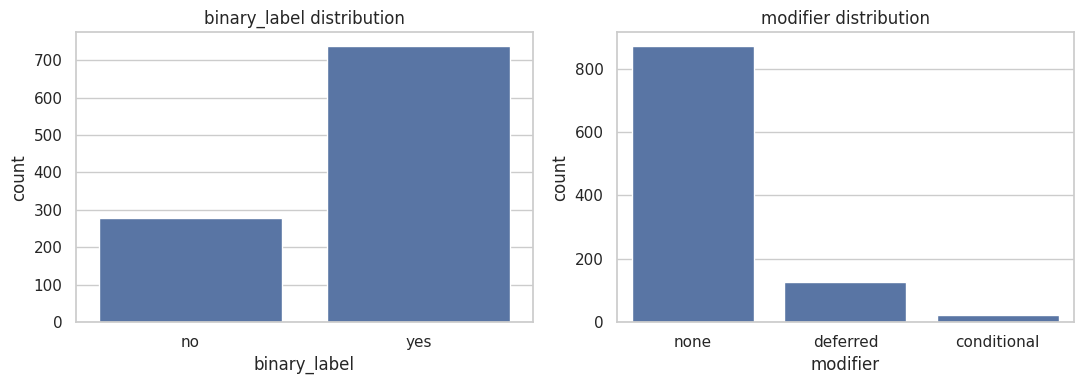


Majority-class baseline (whole dataset, for reference -- the real reported baseline further down uses the TEST split only):
  binary_label: {'majority_class': np.int64(1), 'accuracy': 0.7256637168141593, 'macro_f1': 0.4205128205128205}
  modifier    : {'majority_class': np.int64(0), 'accuracy': 0.856440511307768, 'macro_f1': 0.3075564971751413}


In [4]:
# =============================================================
# 2b. CLASS DISTRIBUTION & MAJORITY-CLASS BASELINE  (unchanged from v3)
# =============================================================
print("binary_label distribution:")
print(df["binary_label"].value_counts(), "\n")
print("modifier distribution:")
print(df["modifier"].value_counts(), "\n")
print("modifier distribution, restricted to binary_label == 'yes' rows "
      "(the population the modifier head is conditioned on):")
print(df.loc[df["binary_label"] == "yes", "modifier"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="binary_label", order=CONFIG["binary_classes"], ax=axes[0])
axes[0].set_title("binary_label distribution")
sns.countplot(data=df, x="modifier", order=CONFIG["modifier_classes"], ax=axes[1])
axes[1].set_title("modifier distribution")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "label_distribution.png"), dpi=150)
plt.show()

def majority_baseline(y_true_ids, n_classes):
    majority_class = Counter(y_true_ids).most_common(1)[0][0]
    y_pred = [majority_class] * len(y_true_ids)
    acc = accuracy_score(y_true_ids, y_pred)
    f1_macro = f1_score(y_true_ids, y_pred, average="macro", labels=list(range(n_classes)), zero_division=0)
    return {"majority_class": majority_class, "accuracy": acc, "macro_f1": f1_macro}

baseline_binary = majority_baseline(df["binary_id"].values, len(CONFIG["binary_classes"]))
baseline_modifier = majority_baseline(df["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("\nMajority-class baseline (whole dataset, for reference -- the real "
      "reported baseline further down uses the TEST split only):")
print("  binary_label:", baseline_binary)
print("  modifier    :", baseline_modifier)

## 3. Stratified 70/15/15 train/val/test split

In [5]:
# =============================================================
# 3. STRATIFIED 70/15/15 SPLIT (by binary_label x modifier combination) -- unchanged from v3
# =============================================================

df["_stratum"] = df["binary_label"] + "_" + df["modifier"]

strat_counts = df["_stratum"].value_counts()
rare = strat_counts[strat_counts < 2].index
df.loc[df["_stratum"].isin(rare), "_stratum"] = "_singleton_bucket"

train_df, temp_df = train_test_split(
    df, test_size=(CONFIG["val_frac"] + CONFIG["test_frac"]),
    stratify=df["_stratum"], random_state=SEED,
)
temp_counts = temp_df["_stratum"].value_counts()
rare2 = temp_counts[temp_counts < 2].index
temp_df = temp_df.copy()
temp_df.loc[temp_df["_stratum"].isin(rare2), "_stratum"] = "_singleton_bucket"

rel_test_size = CONFIG["test_frac"] / (CONFIG["val_frac"] + CONFIG["test_frac"])
val_df, test_df = train_test_split(
    temp_df, test_size=rel_test_size,
    stratify=temp_df["_stratum"], random_state=SEED,
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: n={len(split)} ({len(split)/len(df):.1%})")

print("\nbinary_label composition per split:")
display(pd.concat({
    "train": train_df["binary_label"].value_counts(normalize=True),
    "val": val_df["binary_label"].value_counts(normalize=True),
    "test": test_df["binary_label"].value_counts(normalize=True),
}, axis=1))

print("\nmodifier composition per split:")
display(pd.concat({
    "train": train_df["modifier"].value_counts(normalize=True),
    "val": val_df["modifier"].value_counts(normalize=True),
    "test": test_df["modifier"].value_counts(normalize=True),
}, axis=1))

for split in (train_df, val_df, test_df):
    split.drop(columns=["_stratum"], inplace=True)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train: n=711 (69.9%)
val: n=153 (15.0%)
test: n=153 (15.0%)

binary_label composition per split:


,train,val,test
binary_label,,,
yes,0.724332,0.732026,0.72549
no,0.275668,0.267974,0.27451



modifier composition per split:


,train,val,test
modifier,,,
none,0.856540,0.856209,0.856209
deferred,0.122363,0.124183,0.124183
conditional,0.021097,0.019608,0.019608


## 3b. Data Augmentation (EDA) — TRAIN SPLIT ONLY (v5: fixed)

In [6]:
# =============================================================
# 3b. EDA AUGMENTATION (train split only, label-safety-guarded)  -- v5 FIXES:
#   1. marker-safe tokenizer (regex, not text.split(" "))
#   2. hashlib-based deterministic seeding (not Python's randomized hash())
#   3. Persuadee-turn-biased synonym replacement / insertion
# =============================================================
import re
import random as _random
import hashlib

PROTECTED_WORDS = {
    "if", "unless", "provided", "as", "long", "condition", "conditional",
    "after", "once", "later", "when", "then", "next", "eventually",
    "promise", "will", "would", "could", "might", "may", "maybe",
    "paycheck", "payday", "month", "week", "tomorrow", "soon",
    "not", "no", "never", "don't", "dont", "won't", "wont", "can't", "cant",
    "donate", "donation", "give", "money", "charity", "pledge",
}
SPEAKER_MARKERS = {"[persuader]", "[persuadee]"}

_SYNONYMS = {
    "good": ["nice", "great", "fine", "decent"],
    "really": ["truly", "genuinely", "honestly"],
    "think": ["believe", "feel", "figure"],
    "want": ["would like", "wish", "hope"],
    "help": ["assist", "support", "aid"],
    "people": ["folks", "individuals", "persons"],
    "important": ["significant", "vital", "essential"],
    "cause": ["mission", "campaign", "effort"],
    "understand": ["see", "get", "realize"],
    "sure": ["certain", "confident", "positive"],
    "sorry": ["apologies", "regret", "my bad"],
    "okay": ["alright", "fine", "sure"],
    "thanks": ["thank you", "appreciate it", "cheers"],
    "great": ["awesome", "wonderful", "fantastic"],
    "kids": ["children", "youth", "young ones"],
    "families": ["households", "homes"],
    "problem": ["issue", "trouble", "difficulty"],
    "talk": ["chat", "speak", "discuss"],
    "guess": ["suppose", "reckon", "figure"],
    "job": ["work", "career", "position"],
    "busy": ["swamped", "occupied", "tied up"],
}

def _get_synonym(word):
    lw = word.lower()
    if lw in _SYNONYMS:
        return _random.choice(_SYNONYMS[lw])
    return None

# v5 FIX 1: [Persuader]/[Persuadee] matched as their own atomic token
# FIRST, regardless of what they're glued to. v3/v4 used text.split(" "),
# which only isolates a marker when it happens to already be
# space-delimited -- empirically true for only ~42% of markers in this
# corpus; the other ~58% are glued straight onto "\n" or the previous
# word (e.g. "today?\n[Persuadee]"), so the marker-protection check never
# matched them and they were exposed to swap/delete corruption.
_TOKEN_PATTERN = re.compile(r'\[Persuader\]|\[Persuadee\]|\S+')

def _tokenize_protecting_markers(text):
    return _TOKEN_PATTERN.findall(text)

def _is_locked(tok):
    low = tok.strip(".,!?;:\"'").lower()
    return low in PROTECTED_WORDS or low in SPEAKER_MARKERS or tok.lower() in SPEAKER_MARKERS

def _tag_token_roles(words):
    """Tag each token with its enclosing speaker turn ('persuader' /
    'persuadee' / 'other' before the first marker). Used only to bias
    WHICH words augmentation prefers to touch -- has no effect on the
    actual model's speaker-role embedding, which in v6 is assigned per
    TURN by split_into_utterances() further down (v4/v5's token-level
    compute_batch_role_ids() is not used in this hierarchical model)."""
    roles = []
    current = "other"
    for w in words:
        low = w.lower()
        if low == "[persuader]":
            current = "persuader"
        elif low == "[persuadee]":
            current = "persuadee"
        roles.append(current)
    return roles

def _ranked_candidates(indices, roles, bias_weight):
    """Order candidate indices so Persuadee-turn ones are tried first with
    probability bias_weight -- never excludes Persuader-turn candidates
    outright, since short conditional/deferred dialogues can be almost
    entirely one speaker's words."""
    persuadee = [i for i in indices if roles[i] == "persuadee"]
    other = [i for i in indices if roles[i] != "persuadee"]
    _random.shuffle(persuadee)
    _random.shuffle(other)
    if _random.random() < bias_weight:
        return persuadee + other
    return other + persuadee

def eda_synonym_replacement(words, n, roles=None, bias_weight=0.0):
    new_words = words.copy()
    candidates = [i for i, w in enumerate(new_words) if not _is_locked(w) and _get_synonym(w)]
    if roles is not None and bias_weight > 0:
        candidates = _ranked_candidates(candidates, roles, bias_weight)
    else:
        _random.shuffle(candidates)
    replaced = 0
    for idx in candidates:
        syn = _get_synonym(new_words[idx])
        if syn:
            new_words[idx] = syn
            replaced += 1
        if replaced >= n:
            break
    return new_words

def eda_random_deletion(words, p):
    # Role-agnostic on purpose (see v5 intro cell): deletion is structural
    # noise/shortening, not phrasing diversity, and Persuadee turns can be
    # very short already in conditional/deferred rows.
    if len(words) <= 3:
        return words.copy()
    new_words = []
    for w in words:
        if _is_locked(w):
            new_words.append(w)
        elif _random.random() > p:
            new_words.append(w)
    if len(new_words) == 0:
        return [words[_random.randrange(len(words))]]
    return new_words

def eda_random_swap(words, n):
    # Role-agnostic on purpose -- see eda_random_deletion above.
    new_words = words.copy()
    swappable = [i for i, w in enumerate(new_words) if not _is_locked(w)]
    for _ in range(n):
        if len(swappable) < 2:
            break
        i, j = _random.sample(swappable, 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def eda_random_insertion(words, n, roles=None, bias_weight=0.0):
    # Source word to duplicate-as-synonym is chosen from the ORIGINAL
    # (fixed) word/role list, not the growing new_words list -- keeps
    # role-index alignment simple and correct as the list grows.
    new_words = words.copy()
    base_candidates = [i for i, w in enumerate(words) if not _is_locked(w) and _get_synonym(w)]
    for _ in range(n):
        if not base_candidates:
            break
        if roles is not None and bias_weight > 0:
            idx = _ranked_candidates(base_candidates, roles, bias_weight)[0]
        else:
            idx = _random.choice(base_candidates)
        syn = _get_synonym(words[idx])
        insert_pos = _random.randrange(len(new_words) + 1)
        new_words.insert(insert_pos, syn)
    return new_words

def eda_augment_one(text, alpha=0.15, seed=None, bias_weight=0.0):
    if seed is not None:
        _random.seed(seed)
    words = _tokenize_protecting_markers(text)
    roles = _tag_token_roles(words) if bias_weight > 0 else None
    n_ops = max(1, int(alpha * len(words)))

    op = _random.choice(["synonym", "swap", "delete", "insert"])
    if op == "synonym":
        words = eda_synonym_replacement(words, n_ops, roles=roles, bias_weight=bias_weight)
    elif op == "swap":
        words = eda_random_swap(words, n_ops)
    elif op == "delete":
        words = eda_random_deletion(words, p=alpha)
    else:
        words = eda_random_insertion(words, n_ops, roles=roles, bias_weight=bias_weight)

    return " ".join(words)

# v5 FIX 2: hashlib-based deterministic seed, stable across processes/runs.
# Python's built-in hash() on strings is randomized per-process
# (PYTHONHASHSEED) -- v3/v4's seed=hash((text, k)) % (2**31) silently
# produced different augmented text on every kernel restart despite
# CONFIG["SEED"] being fixed. sha256 is stable by construction.
def _stable_seed(*parts):
    h = hashlib.sha256("::".join(str(p) for p in parts).encode("utf-8")).hexdigest()
    return int(h[:8], 16)

def augment_dataframe_for_minority_classes(df, config, seed=42):
    _random.seed(seed)
    rows_to_add = []
    bias_weight = config.get("aug_persuadee_bias_weight", 0.0)

    yes_idx = config["binary_classes"].index("yes")
    no_idx = config["binary_classes"].index("no")
    cond_idx = config["modifier_classes"].index("conditional")
    def_idx = config["modifier_classes"].index("deferred")

    plan = [
        (df["binary_id"] == yes_idx) & (df["modifier_id"] == cond_idx), config["aug_num_conditional"],
        (df["binary_id"] == yes_idx) & (df["modifier_id"] == def_idx),  config["aug_num_deferred"],
        (df["binary_id"] == no_idx),                                   config["aug_num_no"],
    ]
    for mask, n_copies in zip(plan[0::2], plan[1::2]):
        subset = df.loc[mask]
        for _, row in subset.iterrows():
            for k in range(n_copies):
                aug_text = eda_augment_one(row["text"], alpha=config["aug_alpha"],
                                            seed=_stable_seed(row["text"], k),
                                            bias_weight=bias_weight)
                new_row = row.copy()
                new_row["text"] = aug_text
                rows_to_add.append(new_row)

    if not rows_to_add:
        return df.reset_index(drop=True)

    aug_df = pd.DataFrame(rows_to_add)
    out = pd.concat([df, aug_df], ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


if CONFIG.get("use_augmentation", False):
    _before_n = len(train_df)
    _before_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    train_df = augment_dataframe_for_minority_classes(train_df, CONFIG, seed=SEED)

    _after_n = len(train_df)
    _after_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    print(f"Train split size: {_before_n} -> {_after_n} rows after EDA augmentation")
    print("\nmodifier distribution among binary=yes TRAIN rows, before -> after:")
    display(pd.concat({"before": _before_dist, "after": _after_dist}, axis=1).fillna(0).astype(int))
    print("\nbinary_label distribution after augmentation:")
    print(train_df["binary_label"].value_counts())
else:
    print("Augmentation disabled (CONFIG['use_augmentation'] = False).")

Train split size: 711 -> 1055 rows after EDA augmentation

modifier distribution among binary=yes TRAIN rows, before -> after:


,before,after
modifier,,
none,459,459
deferred,47,141
conditional,9,63



binary_label distribution after augmentation:
binary_label
yes    663
no     392
Name: count, dtype: int64


### 3c. Augmentation QA — marker-integrity self-check (new in v5)

Runs the fixed augmentation against every training row and checks that the number of `[Persuader]`/`[Persuadee]` markers is preserved. On v3/v4's tokenizer this failed on 15.9% of variants; expect ~0% here.

In [7]:
# =============================================================
# 3c. AUGMENTATION QA -- marker-integrity self-check (v5)
# =============================================================
_marker_pattern = re.compile(r'\[Persuader\]|\[Persuadee\]')

def _marker_count(t):
    return len(_marker_pattern.findall(t))

_n_checked = 0
_n_mismatch = 0
_mismatch_examples = []
_bias_weight = CONFIG.get("aug_persuadee_bias_weight", 0.0)

for _, _row in train_df.iterrows():
    _orig_markers = _marker_count(_row["text"])
    if _orig_markers == 0:
        continue
    for _k in range(3):
        _aug_text = eda_augment_one(_row["text"], alpha=CONFIG["aug_alpha"],
                                     seed=_stable_seed(_row["text"], f"qa{_k}"),
                                     bias_weight=_bias_weight)
        _aug_markers = _marker_count(_aug_text)
        _n_checked += 1
        if _aug_markers != _orig_markers:
            _n_mismatch += 1
            if len(_mismatch_examples) < 3:
                _mismatch_examples.append((_orig_markers, _aug_markers, _row["text"][:100], _aug_text[:100]))

print(f"Checked {_n_checked} augmented variants across {len(train_df)} (post-augmentation) train rows.")
print(f"Marker-count mismatches: {_n_mismatch} ({_n_mismatch / max(_n_checked, 1):.2%})")
if _mismatch_examples:
    print("\nExample mismatches:")
    for _o, _a, _ot, _at in _mismatch_examples:
        print(f"  orig_markers={_o} aug_markers={_a}\n    ORIG: {_ot!r}\n    AUG : {_at!r}")
else:
    print("No marker corruption detected.")


Checked 3165 augmented variants across 1055 (post-augmentation) train rows.
Marker-count mismatches: 0 (0.00%)
No marker corruption detected.


## 4. Dataset, utterance splitting & hierarchical batching (v6)

In [8]:
# =============================================================
# 4. TORCH DATASET + UTTERANCE SPLITTING + HIERARCHICAL COLLATE  (v6)
# =============================================================
import re

_SPEAKER_PATTERN = re.compile(r'\[Persuader\]|\[Persuadee\]')
ROLE_PERSUADER = 0
ROLE_PERSUADEE = 1
ROLE_PAD       = 2   # padding turn-slot (dialogue shorter than batch max)


class DonationIntentDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.binary_ids = dataframe["binary_id"].tolist()
        self.modifier_ids = dataframe["modifier_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "binary_id": self.binary_ids[idx],
            "modifier_id": self.modifier_ids[idx],
        }


def split_into_utterances(text, max_utterances=32):
    """
    Split a dialogue into (speaker_role, utterance_text) turns using
    [Persuader]/[Persuadee] markers located by regex POSITION -- not
    text.split(" ") -- so this is robust regardless of whether a marker
    is glued to surrounding whitespace/punctuation (57.5% of markers in
    this corpus are glued to a preceding "\n" with no space; see v5's
    augmentation fix for the full measurement).

    If a dialogue has more than max_utterances turns, the EARLIEST turns
    are dropped and the most recent max_utterances are kept -- donation
    intent is usually resolved near the end of a conversation
    (guideline.md: "use the persuadee's last clear position"). In
    practice this corpus never exceeds 30 turns, so with the default
    max_utterances=32 this branch does not fire.
    """
    matches = list(_SPEAKER_PATTERN.finditer(text))
    utterances = []
    for i, m in enumerate(matches):
        role = ROLE_PERSUADER if m.group() == "[Persuader]" else ROLE_PERSUADEE
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        utt_text = text[start:end].strip()
        if utt_text:
            utterances.append((role, utt_text))
    if len(utterances) > max_utterances:
        utterances = utterances[-max_utterances:]
    return utterances


def make_hier_collate_fn(tokenizer, max_utt_len, max_utterances):
    """
    Builds a batch of shape [B, U, L] (U = max turns present in this
    batch, L = max tokens across all turns in this batch, both dynamic --
    not padded to the global max_utterances/max_utt_len caps) plus:
      - utt_mask [B, U]  : 1 = real turn, 0 = padding turn-slot
      - role_ids [B, U]  : ROLE_PERSUADER / ROLE_PERSUADEE / ROLE_PAD

    Padding turn-slots (dialogues shorter than this batch's U) get a
    single valid dummy token (the tokenizer's CLS/BOS id, attention_mask=1
    at position 0 only) rather than an all-zero attention mask -- avoids
    relying on every encoder implementation handling a fully-masked
    sequence identically; utt_mask excludes these slots from both the
    dialogue transformer (src_key_padding_mask) and the final attention
    pooling, so their (unused) encoded vector never reaches the heads.
    """
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    cls_id = tokenizer.cls_token_id
    if cls_id is None:
        cls_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else pad_id

    def collate_fn(batch):
        all_utts = []
        for b in batch:
            utts = split_into_utterances(b["text"], max_utterances=max_utterances)
            if not utts:
                utts = [(ROLE_PERSUADEE, "")]   # degenerate fallback, should not occur on this corpus
            all_utts.append(utts)

        B = len(all_utts)
        U = max(len(u) for u in all_utts)

        flat_texts, flat_roles, owner = [], [], []
        for di, utts in enumerate(all_utts):
            for ui, (role, text) in enumerate(utts):
                flat_texts.append(text if text.strip() else " ")
                flat_roles.append(role)
                owner.append((di, ui))

        enc = tokenizer(flat_texts, padding=True, truncation=True,
                         max_length=max_utt_len, return_tensors="pt")
        L = enc["input_ids"].shape[1]

        input_ids = torch.full((B, U, L), pad_id, dtype=torch.long)
        attn_mask = torch.zeros(B, U, L, dtype=torch.long)
        utt_mask  = torch.zeros(B, U, dtype=torch.long)
        role_ids  = torch.full((B, U), ROLE_PAD, dtype=torch.long)

        input_ids[:, :, 0] = cls_id   # safe dummy token everywhere, overwritten below for real turns

        for flat_idx, (di, ui) in enumerate(owner):
            input_ids[di, ui] = enc["input_ids"][flat_idx]
            attn_mask[di, ui] = enc["attention_mask"][flat_idx]
            utt_mask[di, ui] = 1
            role_ids[di, ui] = flat_roles[flat_idx]

        pad_slot = (utt_mask == 0)
        attn_mask[:, :, 0] = attn_mask[:, :, 0].masked_fill(pad_slot, 1)

        return {
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "utt_mask": utt_mask,
            "role_ids": role_ids,
            "binary_labels":   torch.tensor([b["binary_id"]   for b in batch], dtype=torch.long),
            "modifier_labels": torch.tensor([b["modifier_id"] for b in batch], dtype=torch.long),
        }
    return collate_fn

## 5. Model architecture — dual-stream Persuader/Persuadee cross-attention (v14-antiphony, new)

```
input_ids, attention_mask   [B, U, L]
        |
   flatten [B*U, L], ONE batched forward pass through the shared
   utterance encoder (RoBERTa-base | DeBERTa-v3-base | TOD-BERT)
   -- UNCHANGED from every prior notebook
        |
   masked mean-pool each turn -> [B*U, H] -> reshape [B, U, H]
        |
   split by role_ids/utt_mask into two role-pure streams,
   each right-padded to max_role_len, LAST max_role_len real
   turns kept per role (chronological order preserved)
        |
   +-------------------------+     +-------------------------+
   |   Persuader stream      |     |   Persuadee stream      |
   |   [B, R, H]             |     |   [B, R, H]              |
   |   + stream position emb |     |   + stream position emb  |
   |   persuader_transformer |     |   persuadee_transformer  |
   |   (2 layers)             |     |   (2 layers)              |
   +-------------------------+     +-------------------------+
              |                              |
              |   key/value            query |
              +----------> Cross-Attention <-+
                            (Persuadee queries Persuader:
                             "how does the decision-maker's
                             stance respond to what was argued")
                                     |
                          persuadee_final = LayerNorm(
                              persuadee_encoded + cross_out)
                                     |
                    +----------------+----------------+
                    |                                 |
          Attention Pooling                  Commitment-Trajectory GRU
          "what mattered most,                "how commitment built up,
           overall" (same mechanism            turn by turn" -- FINAL
           used elsewhere, scoped to            hidden state, read at
           this stream)                          each row's true last
                    |                             valid Persuadee turn
              pooled_summary [B,H]                trajectory_vec [B,H]
                    |                                 |
                    +----------------+----------------+
                                     |
                    shared = concat([pooled_summary, trajectory_vec])  [B, 2H]
                                     |
                               binary_head
                                     |
                              binary_logits
```

Why each piece:

- **Speaker-disentangled streams**: splitting by role *before* any
  discourse-level attention means each stream's Transformer only ever
  sees turns from one speaker, in their own chronological order --
  modeling how the persuader's own argument develops, and how the
  persuadee's own stance develops, without either signal contaminating
  the other before the model has had a chance to reason about them
  separately.
- **Directional cross-attention** (Persuadee queries Persuader): makes
  the "who is responding to whom" structure explicit and asymmetric,
  rather than relying on a role embedding to be rediscovered inside one
  symmetric self-attention pass over both roles mixed together.
- **Commitment-trajectory GRU**: a recurrent final-hidden-state readout
  is a genuinely different signal from an attention-pooled snapshot --
  it summarizes *how the sequence evolved*, not just *what mattered
  most*. No hand-tuned recency scalar is needed (contrast v10-coda's
  `recency_strength`): a GRU's hidden state is inherently shaped more by
  recent inputs, so sequential recency is an emergent property of the
  mechanism itself, not a hyperparameter.
- **Both pooled_summary and trajectory_vec are kept**, concatenated: one
  is a permutation-invariant "what mattered" summary, the other is an
  order-sensitive "how it built up" summary. Feeding the classifier both
  lets training decide how much weight each deserves, rather than
  committing to one view of the stream up front.


In [9]:
# =============================================================
# 5. DUAL-STREAM PERSUADER/PERSUADEE CROSS-ATTENTION  (v14-antiphony, new architecture)
# =============================================================

class AntiphonyClassifier(nn.Module):
    """
    Dual-stream, speaker-disentangled encoder for persuasion dialogues.

    After the shared per-turn utterance encoding (unchanged from every
    prior notebook), turn vectors are split by role into a Persuader
    stream and a Persuadee stream, each in their own chronological
    order, each given its OWN small Transformer -- modeling how each
    party's own argument/stance develops across their own turns,
    independent of interleaving (same family of idea as DialogueRNN's
    per-party state tracking, Majumder et al. 2019, adapted here for
    persuasion outcome rather than emotion recognition).

    The Persuadee stream then cross-attends over the Persuader stream
    (Persuadee as query, Persuader as key/value) -- an explicit,
    directional "how does the decision-maker's stance respond to what
    was argued" mechanism ("antiphony": alternating call-and-response
    between two distinct voices).

    A GRU over the cross-attended Persuadee stream's own chronological
    order gives a "commitment trajectory" signal from its FINAL hidden
    state -- how the decision built up turn by turn -- concatenated with
    an attention-pooled summary of the same stream before the binary
    head. Returns (binary_logits, shared) -- same 2-tuple contract as
    v13-solo's model, so nothing in the training loop needs to change.
    """

    ROLE_PERSUADER_ID = 0
    ROLE_PERSUADEE_ID = 1  # matches ROLE_PERSUADEE defined in the dataset/collate cell above

    def __init__(self, hf_id, n_binary, dropout=0.1,
                 stream_layers=2, stream_heads=8, cross_heads=8, max_role_len=20):
        super().__init__()
        self.utt_encoder = AutoModel.from_pretrained(hf_id)
        # Gradient checkpointing (unchanged from v6's OOM fix).
        if hasattr(self.utt_encoder, "gradient_checkpointing_enable"):
            self.utt_encoder.gradient_checkpointing_enable()
        hidden = self.utt_encoder.config.hidden_size
        self.max_role_len = max_role_len
        self.dropout = nn.Dropout(dropout)

        # Within-stream chronological position -- each stream is
        # role-pure, so a role embedding would be redundant here; what
        # matters is "this is this speaker's Nth turn".
        self.stream_pos_embedding = nn.Embedding(max_role_len, hidden)
        nn.init.normal_(self.stream_pos_embedding.weight, std=0.02)

        persuader_layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=stream_heads, dim_feedforward=hidden * 4,
            dropout=dropout, activation="gelu", batch_first=True)
        self.persuader_transformer = nn.TransformerEncoder(persuader_layer, num_layers=stream_layers)

        persuadee_layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=stream_heads, dim_feedforward=hidden * 4,
            dropout=dropout, activation="gelu", batch_first=True)
        self.persuadee_transformer = nn.TransformerEncoder(persuadee_layer, num_layers=stream_layers)

        # Cross-attention: the Persuadee stream queries the Persuader
        # stream -- models influence direction explicitly, rather than a
        # symmetric self-attention pass over both roles mixed together.
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden, num_heads=cross_heads, dropout=dropout, batch_first=True)
        self.cross_norm = nn.LayerNorm(hidden)

        # Attention pooling over the cross-attended Persuadee stream --
        # "what mattered most, overall" (same mechanism used everywhere
        # else in this project, just scoped to one role's stream now).
        self.attn_proj  = nn.Linear(hidden, hidden)
        self.attn_score = nn.Linear(hidden, 1, bias=False)

        # Commitment-trajectory GRU over the same stream, in
        # chronological order -- its FINAL hidden state is "how did
        # commitment build up", a genuinely different signal from the
        # pooled "what mattered most" summary above. A GRU's hidden
        # state is inherently more shaped by recent inputs, so recency
        # emerges from this head's own inductive bias -- no hand-tuned
        # recency scalar needed (contrast v10-coda's recency_strength).
        self.trajectory_gru = nn.GRU(hidden, hidden, batch_first=True)

        self.binary_head = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_binary),
        )

    def _encode_turns(self, input_ids, attention_mask):
        """[B, U, L] -> [B, U, H] via one flattened forward pass through
        the shared utterance encoder + masked mean-pool per turn.
        Unchanged from every prior notebook -- this part is proven."""
        B, U, L = input_ids.shape
        flat_ids  = input_ids.view(B * U, L)
        flat_mask = attention_mask.view(B * U, L)

        outputs = self.utt_encoder(input_ids=flat_ids, attention_mask=flat_mask)
        flat_hidden = outputs.last_hidden_state             # [B*U, L, H]

        mask = flat_mask.unsqueeze(-1).float()
        summed = (flat_hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        turn_vecs = summed / counts                          # [B*U, H]

        return turn_vecs.view(B, U, -1)

    def _split_by_role(self, turn_vecs, role_ids, utt_mask, role_id_value):
        """
        turn_vecs: [B, U, H]. Returns (role_vecs [B, R, H], role_mask
        [B, R]) for the given role, right-padded, keeping the LAST
        `max_role_len` real turns of that role in original chronological
        order (mirrors the project-wide convention of preserving a
        dialogue's closing turns under truncation).
        """
        B, U, H = turn_vecs.shape
        R = self.max_role_len
        device = turn_vecs.device
        out = turn_vecs.new_zeros(B, R, H)
        out_mask = torch.zeros(B, R, dtype=torch.bool, device=device)
        role_match = (role_ids == role_id_value) & (utt_mask == 1)
        for b in range(B):
            idx = torch.nonzero(role_match[b], as_tuple=True)[0]
            if idx.numel() > R:
                idx = idx[-R:]
            n = idx.numel()
            if n > 0:
                out[b, :n] = turn_vecs[b, idx]
                out_mask[b, :n] = True
        return out, out_mask

    def forward(self, input_ids, attention_mask, utt_mask, role_ids, **_):
        turn_vecs = self._encode_turns(input_ids, attention_mask)   # [B, U, H]

        persuader_vecs, persuader_mask = self._split_by_role(
            turn_vecs, role_ids, utt_mask, self.ROLE_PERSUADER_ID)
        persuadee_vecs, persuadee_mask = self._split_by_role(
            turn_vecs, role_ids, utt_mask, self.ROLE_PERSUADEE_ID)

        R = self.max_role_len
        stream_positions = torch.arange(R, device=turn_vecs.device).unsqueeze(0)
        pos_emb = self.stream_pos_embedding(stream_positions)        # [1, R, H]
        persuader_vecs = persuader_vecs + pos_emb
        persuadee_vecs = persuadee_vecs + pos_emb

        persuader_encoded = self.persuader_transformer(
            persuader_vecs, src_key_padding_mask=~persuader_mask)    # [B, R, H]
        persuadee_encoded = self.persuadee_transformer(
            persuadee_vecs, src_key_padding_mask=~persuadee_mask)    # [B, R, H]

        # Persuadee stream queries the Persuader stream: "what did the
        # persuader argue that's relevant to how I respond".
        cross_out, _ = self.cross_attn(
            query=persuadee_encoded, key=persuader_encoded, value=persuader_encoded,
            key_padding_mask=~persuader_mask)
        persuadee_final = self.cross_norm(persuadee_encoded + cross_out)   # [B, R, H]

        # (a) Attention-pooled summary -- "what mattered most, overall".
        scores = self.attn_score(torch.tanh(self.attn_proj(persuadee_final))).squeeze(-1)
        scores = scores.masked_fill(~persuadee_mask, float("-inf"))
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)
        pooled_summary = (persuadee_final * weights).sum(dim=1)      # [B, H]

        # (b) Commitment-trajectory: GRU final hidden state at each
        # row's true last valid Persuadee turn (never a padding slot).
        lengths = persuadee_mask.sum(dim=1).clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(
            persuadee_final, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.trajectory_gru(packed)
        trajectory_vec = h_n.squeeze(0)                               # [B, H]

        shared = self.dropout(torch.cat([pooled_summary, trajectory_vec], dim=-1))  # [B, 2H]
        binary_logits = self.binary_head(shared)

        return binary_logits, shared


## 6. Loss — Class-Balanced Focal Loss + Supervised Contrastive (unchanged from v4/v5)

Replaces v3's `CrossEntropyLoss(weight=inverse_freq, label_smoothing=0.1)`
on both heads.

**Class-Balanced Focal Loss** (Cui et al., 2019, CVPR): class weights come
from the *effective number of samples* `(1 - beta^n) / (1 - beta)` rather
than raw inverse frequency — this saturates gracefully for near-zero-sample
classes like `conditional` (~9-13 real train rows) instead of assigning an
enormous, unstable weight. On top of that, the focal term
`(1-p_t)^gamma` keeps discounting *already-easy* predictions for the whole
run, so a model that starts predicting the majority class confidently
doesn't get to coast on a fixed loss scale the way plain weighted CE
allows.

**Supervised Contrastive loss** (Khosla et al., 2020), computed in-batch
on `shared_repr`: for each anchor with at least one same-class partner in
the batch, pulls same-class pooled vectors together and pushes different-
class ones apart via a batch similarity matrix. This is a single-stage
stand-in for README idea #3 (full SimCSE needs an unsupervised
pretraining stage) — it adds one `B x B` matmul on vectors already
computed for the forward pass, so it is effectively free compute-wise.
Applied to binary labels (small weight) and, more heavily, to modifier
labels restricted to `binary_label == "yes"` rows (the class that
collapses hardest).

In [10]:
# =============================================================
# 6. CLASS-BALANCED FOCAL LOSS + SUPERVISED CONTRASTIVE LOSS  (v4)
# =============================================================

class ClassBalancedFocalLoss(nn.Module):
    """Cui et al. (2019) class-balanced re-weighting (effective number of
    samples) combined with the focal-loss focusing term (Lin et al., 2017).
    """
    def __init__(self, samples_per_class, beta=0.999, gamma=2.0):
        super().__init__()
        samples_per_class = np.asarray(samples_per_class, dtype=np.float64)
        samples_per_class = np.clip(samples_per_class, 1.0, None)  # avoid beta**0 edge case
        effective_num = 1.0 - np.power(beta, samples_per_class)
        effective_num = np.where(effective_num <= 0, 1e-8, effective_num)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("class_weights", torch.tensor(weights, dtype=torch.float32))
        self.gamma = gamma

    def forward(self, logits, targets):
        if logits.size(0) == 0:
            return torch.zeros((), device=logits.device)
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        pt     = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha_t = self.class_weights.to(logits.device)[targets]
        loss = -alpha_t * (1 - pt).pow(self.gamma) * log_pt
        return loss.mean()


def supervised_contrastive_loss(pooled, labels, temperature=0.1):
    """
    In-batch supervised contrastive loss (Khosla et al., 2020), single-view.
    For each anchor with >=1 same-class partner in the batch, pulls its
    representation toward same-class partners and away from the rest.
    Anchors with zero same-class partners in the batch contribute nothing
    (common in small batches with rare classes -- this is expected).
    """
    n = pooled.size(0)
    if n < 2:
        return torch.zeros((), device=pooled.device)

    z = F.normalize(pooled, dim=-1)
    sim = torch.matmul(z, z.T) / temperature                    # [B, B]

    labels = labels.view(-1, 1)
    same_class  = (labels == labels.T).float()
    self_mask   = torch.eye(n, device=z.device)
    positive_mask = same_class - self_mask

    logits_max, _ = sim.max(dim=1, keepdim=True)
    logits = sim - logits_max.detach()
    exp_logits = torch.exp(logits) * (1 - self_mask)
    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

    pos_counts = positive_mask.sum(dim=1)
    valid = pos_counts > 0
    if valid.sum() == 0:
        return torch.zeros((), device=pooled.device)

    mean_log_prob_pos = (positive_mask * log_prob).sum(dim=1)[valid] / pos_counts[valid]
    return -mean_log_prob_pos.mean()


def samples_per_class(ids, n_classes):
    counts = np.bincount(ids, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0  # absent-in-train class: treat as 1 to avoid div issues
    return counts

binary_samples_per_class = samples_per_class(train_df["binary_id"].values, len(CONFIG["binary_classes"]))

print("binary_label samples/class (train):", dict(zip(CONFIG["binary_classes"], binary_samples_per_class.tolist())))

binary_focal_loss_fn = ClassBalancedFocalLoss(
    binary_samples_per_class, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"])

print("\nClass-balanced weights (effective-number-of-samples, beta="
      f"{CONFIG['cb_beta']}):")
print("  binary:  ", dict(zip(CONFIG["binary_classes"], binary_focal_loss_fn.class_weights.tolist())))

binary_label samples/class (train): {'no': 392.0, 'yes': 663.0}

Class-balanced weights (effective-number-of-samples, beta=0.999):
  binary:   {'no': 1.198245644569397, 'yes': 0.8017544150352478}


## 7. Training / eval functions (v6)

Same shape as v4/v5 (class-balanced focal + supervised contrastive loss,
binary-macro-F1 checkpoint selection, val-tuned threshold search, early
stopping) — `compute_losses`, `evaluate`, and `find_optimal_binary_threshold`
are unchanged verbatim, since they only touch `(binary_logits,
modifier_logits, shared)` and label tensors, not the model's internals.
`train_one_encoder` is updated for: the hierarchical collate function,
the new model constructor arguments, and moving the extra `utt_mask` /
`role_ids` batch keys to device alongside the rest.

In [11]:
# =============================================================
# 7. TRAIN / EVAL FUNCTIONS  (binary-only, unchanged from v13-solo --
#    no modifier_logits, no modifier_labels, no averaged selection metric)
# =============================================================

def compute_losses(binary_logits, shared, binary_labels, include_contrastive):
    """Shared loss computation used by both the training step and evaluate()."""
    binary_loss = binary_focal_loss_fn(binary_logits, binary_labels)
    total = CONFIG["binary_loss_weight"] * binary_loss

    if include_contrastive and CONFIG.get("use_contrastive", False):
        con_binary = supervised_contrastive_loss(
            shared, binary_labels, temperature=CONFIG["contrastive_temperature"])
        total = total + CONFIG["contrastive_weight_binary"] * con_binary

    return total


def evaluate(model, loader, device, binary_threshold=0.5):
    """
    Evaluate model on a DataLoader.

    binary_threshold : float
        P(yes) >= binary_threshold -> predict 'yes'.
    """
    model.eval()
    all_binary_true, all_binary_pred = [], []
    all_binary_probs = []
    total_loss = 0.0
    n_batches  = 0
    yes_idx    = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in loader:
            binary_labels = batch.pop("binary_labels").to(device)
            batch.pop("modifier_labels")  # unused -- no modifier head in v13-solo
            batch = {k: v.to(device) for k, v in batch.items()}

            binary_logits, shared = model(**batch)

            # Eval loss reported WITHOUT the contrastive term (it's a
            # representation-shaping regulariser for training, not a
            # meaningful "how good are these predictions" number).
            loss = compute_losses(binary_logits, shared, binary_labels,
                                   include_contrastive=False)
            total_loss += loss.item()
            n_batches  += 1

            binary_probs_yes = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            binary_preds     = (binary_probs_yes >= binary_threshold).long()

            all_binary_true.extend(binary_labels.cpu().tolist())
            all_binary_pred.extend(binary_preds.cpu().tolist())
            all_binary_probs.extend(binary_probs_yes.cpu().tolist())

    binary_acc      = accuracy_score(all_binary_true, all_binary_pred)
    binary_f1       = f1_score(all_binary_true, all_binary_pred, average="binary",
                                pos_label=yes_idx, zero_division=0)
    binary_macro_f1 = f1_score(all_binary_true, all_binary_pred, average="macro",
                                labels=[0, 1], zero_division=0)

    return {
        "loss":            total_loss / max(n_batches, 1),
        "binary_accuracy": binary_acc,
        "binary_f1":       binary_f1,
        "binary_macro_f1": binary_macro_f1,
        "binary_true":     all_binary_true,
        "binary_pred":     all_binary_pred,
        "binary_probs":    all_binary_probs,
    }


def find_optimal_binary_threshold(model, val_loader, device):
    """Grid-search for the binary threshold that maximises macro-F1 on val."""
    model.eval()
    all_true, all_probs = [], []
    yes_idx = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in val_loader:
            binary_labels = batch.pop("binary_labels").to(device)
            batch.pop("modifier_labels")
            batch = {k: v.to(device) for k, v in batch.items()}
            binary_logits, _ = model(**batch)
            probs = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            all_true.extend(binary_labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    best_threshold, best_macro_f1 = 0.5, 0.0
    for t in [v / 100 for v in range(10, 91, 5)]:
        preds    = [1 if p >= t else 0 for p in all_probs]
        macro_f1 = f1_score(all_true, preds, average="macro",
                             labels=[0, 1], zero_division=0)
        if macro_f1 > best_macro_f1:
            best_macro_f1, best_threshold = macro_f1, t

    return best_threshold, best_macro_f1


def train_one_encoder(encoder_cfg, train_df, val_df, test_df):
    name, hf_id    = encoder_cfg["name"], encoder_cfg["hf_id"]
    sep_line       = "=" * 70
    print(f"\n{sep_line}\nTraining {name} ({hf_id})  [binary-only, antiphony architecture]"
          f"  [max_role_len={CONFIG['antiphony_max_role_len']}, "
          f"stream_layers={CONFIG['antiphony_stream_layers']}]"
          f"  [contrastive={'ON' if CONFIG.get('use_contrastive') else 'OFF'}]\n{sep_line}")

    tokenizer  = AutoTokenizer.from_pretrained(hf_id)
    collate_fn = make_hier_collate_fn(tokenizer, CONFIG["max_utt_len"],
                                       CONFIG["max_utterances"])

    train_ds = DonationIntentDataset(train_df)
    val_ds   = DonationIntentDataset(val_df)
    test_ds  = DonationIntentDataset(test_df)

    enc_batch_size = encoder_cfg.get("batch_size", CONFIG["batch_size"])
    enc_eval_batch_size = encoder_cfg.get("eval_batch_size", CONFIG["eval_batch_size"])
    train_loader = DataLoader(train_ds, batch_size=enc_batch_size,
                               shuffle=True, collate_fn=collate_fn)
    val_loader  = DataLoader(val_ds,  batch_size=enc_eval_batch_size,
                              shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=enc_eval_batch_size,
                              shuffle=False, collate_fn=collate_fn)

    model = AntiphonyClassifier(
        hf_id,
        n_binary=len(CONFIG["binary_classes"]),
        stream_layers=CONFIG["antiphony_stream_layers"],
        stream_heads=CONFIG["antiphony_stream_heads"],
        cross_heads=CONFIG["antiphony_cross_heads"],
        max_role_len=CONFIG["antiphony_max_role_len"],
    ).to(DEVICE)

    yes_idx = CONFIG["binary_classes"].index("yes")

    encoder_lr = encoder_cfg.get("lr", CONFIG["lr"])
    optimizer  = torch.optim.AdamW(model.parameters(), lr=encoder_lr,
                                    weight_decay=CONFIG["weight_decay"], eps=1e-6)
    total_steps = len(train_loader) * CONFIG["num_epochs"]
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * encoder_cfg.get("warmup_ratio", CONFIG["warmup_ratio"])),
        num_training_steps=total_steps,
    )

    ckpt_path            = os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"],
                                        f"{name}_best.pt")
    best_val_score       = -1.0
    epochs_without_improve = 0
    history              = []

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        model.train()
        running_loss = 0.0
        _n = CONFIG["num_epochs"]
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch}/{_n}")

        for batch in pbar:
            binary_labels = batch.pop("binary_labels").to(DEVICE)
            batch.pop("modifier_labels")
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            optimizer.zero_grad()
            binary_logits, shared = model(**batch)

            loss = compute_losses(binary_logits, shared, binary_labels,
                                   include_contrastive=True)

            if torch.isnan(loss):
                print("  [WARNING] NaN loss detected -- skipping batch.")
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        val_metrics = evaluate(model, val_loader, DEVICE, binary_threshold=0.5)
        # v13-solo: selection metric is binary_macro_f1 alone -- no more
        # averaging with a noisy, low-support modifier score.
        val_score   = val_metrics["binary_macro_f1"]
        history.append({
            "epoch":               epoch,
            "train_loss":          running_loss / len(train_loader),
            "val_loss":            val_metrics["loss"],
            "val_binary_f1":       val_metrics["binary_f1"],
            "val_binary_macro_f1": val_metrics["binary_macro_f1"],
            "val_binary_accuracy": val_metrics["binary_accuracy"],
        })
        _tl = history[-1]["train_loss"]
        _bmf = val_metrics["binary_macro_f1"]
        print(f"  epoch {epoch}: train_loss={_tl:.4f} val_binary_macroF1={_bmf:.4f}")

        if val_score > best_val_score:
            best_val_score       = val_score
            epochs_without_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best (binary_macroF1={val_score:.4f}), checkpoint saved.")
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= CONFIG["early_stopping_patience"]:
                print(f"  -> no improvement for {epochs_without_improve} epochs, stopping early.")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    best_thresh, thresh_val_macro_f1 = find_optimal_binary_threshold(
        model, val_loader, DEVICE)
    print(f"\n  Threshold search -> best thresh={best_thresh:.2f}"
          f"  (val macro-F1={thresh_val_macro_f1:.4f})")

    test_m_default = evaluate(model, test_loader, DEVICE, binary_threshold=0.5)
    test_m_tuned   = evaluate(model, test_loader, DEVICE, binary_threshold=best_thresh)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "name":                 name,
        "hf_id":                hf_id,
        "history":              history,
        "test_metrics":         test_m_tuned,
        "test_metrics_default": test_m_default,
        "test_binary_accuracy": test_m_tuned["binary_accuracy"],
        "test_binary_f1":       test_m_tuned["binary_f1"],
        "test_binary_macro_f1": test_m_tuned["binary_macro_f1"],
        "best_threshold":       best_thresh,
        "ckpt_path":            ckpt_path,
    }


## 8. Run training for all three encoders

In [12]:
# =============================================================
# 8. RUN ALL THREE ENCODERS (binary-only)
# =============================================================
results = {}
for encoder_cfg in CONFIG["encoders"]:
    results[encoder_cfg["name"]] = train_one_encoder(encoder_cfg, train_df, val_df, test_df)

print("\nDone training all encoders:", list(results.keys()))


Training roberta-base (roberta-base)  [binary-only, antiphony architecture]  [max_role_len=20, stream_layers=2]  [contrastive=ON]


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  epoch 10: train_loss=0.3715 val_binary_macroF1=0.8379


[todbert] epoch 11/25:   0%|          | 0/132 [00:00<?, ?it/s]

  epoch 11: train_loss=0.3802 val_binary_macroF1=0.8249


[todbert] epoch 12/25:   0%|          | 0/132 [00:00<?, ?it/s]

  epoch 12: train_loss=0.3737 val_binary_macroF1=0.8351
  -> no improvement for 5 epochs, stopping early.

  Threshold search -> best thresh=0.45  (val macro-F1=0.8405)

Done training all encoders: ['roberta-base', 'deberta-v3-base', 'todbert']


In [13]:
# =============================================================
# 8b. THRESHOLD COMPARISON TABLE
# =============================================================
print(f"\n{'='*70}")
print("Binary head: default threshold (0.5) vs val-tuned threshold")
print(f"{'='*70}")
header = f"{'Model':<20} {'Thresh':>6}  {'Binary Acc':>10}  {'Bin MacroF1':>11}  "
header += f"{'no F1':>8}  {'yes F1':>8}"
print(header)
print("-" * len(header))

for name, r in results.items():
    for label, tm, thresh in [
        ("(default)", r["test_metrics_default"], 0.5),
        ("(tuned)",   r["test_metrics"],         r["best_threshold"]),
    ]:
        from sklearn.metrics import f1_score as _f1
        no_f1  = _f1(tm["binary_true"], tm["binary_pred"], pos_label=0,
                      average="binary", zero_division=0)
        yes_f1 = _f1(tm["binary_true"], tm["binary_pred"], pos_label=1,
                      average="binary", zero_division=0)
        row = (f"{name+' '+label:<20} {thresh:>6.2f}  "
               f"{tm['binary_accuracy']:>10.4f}  {tm['binary_macro_f1']:>11.4f}  "
               f"{no_f1:>8.4f}  {yes_f1:>8.4f}")
        print(row)
    print()



Binary head: default threshold (0.5) vs val-tuned threshold
Model                Thresh  Binary Acc  Bin MacroF1     no F1    yes F1
------------------------------------------------------------------------
roberta-base (default)   0.50      0.8824       0.8477    0.7750    0.9204
roberta-base (tuned)   0.90      0.8889       0.8595    0.7952    0.9238

deberta-v3-base (default)   0.50      0.8954       0.8623    0.7949    0.9298
deberta-v3-base (tuned)   0.20      0.8954       0.8600    0.7895    0.9304

todbert (default)      0.50      0.8693       0.8308    0.7500    0.9115
todbert (tuned)        0.45      0.8758       0.8379    0.7595    0.9163



## 9. Test-set majority-class baseline (matched to the actual test split)

In [14]:
# =============================================================
# 9. TEST-SET MAJORITY-CLASS BASELINE
# =============================================================
train_majority_binary = Counter(train_df["binary_id"]).most_common(1)[0][0]

test_binary_true = test_df["binary_id"].values
baseline_test_binary_pred = [train_majority_binary] * len(test_df)

baseline_row = {
    "model": "majority_baseline",
    "binary_accuracy": accuracy_score(test_binary_true, baseline_test_binary_pred),
    "binary_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="binary",
                           pos_label=CONFIG["binary_classes"].index("yes"), zero_division=0),
    "binary_macro_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="macro",
                                 labels=[0, 1], zero_division=0),
}
print("Majority-class baseline on TEST split:")
print(json.dumps(baseline_row, indent=2))


Majority-class baseline on TEST split:
{
  "model": "majority_baseline",
  "binary_accuracy": 0.7254901960784313,
  "binary_f1": 0.8409090909090909,
  "binary_macro_f1": 0.42045454545454547
}


## 10. Results summary table — v14-antiphony vs. majority baseline


In [15]:
# =============================================================
# 10. RESULTS SUMMARY
# =============================================================
summary_rows = [baseline_row]
for name, r in results.items():
    summary_rows.append({
        "model": name,
        "binary_accuracy": r["test_binary_accuracy"],
        "binary_f1": r["test_binary_f1"],
        "binary_macro_f1": r["test_binary_macro_f1"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(CONFIG["out_dir"], f"classifier_test_results_{CONFIG['run_tag']}.csv"), index=False)
display(summary_df)


,model,binary_accuracy,binary_f1,binary_macro_f1
0,majority_baseline,0.725490,0.840909,0.420455
1,roberta-base,0.888889,0.923767,0.859474
2,deberta-v3-base,0.895425,0.930435,0.859954
3,todbert,0.875817,0.916300,0.837897


### 10a. Bar chart — accuracy/F1 comparison across encoders + baseline

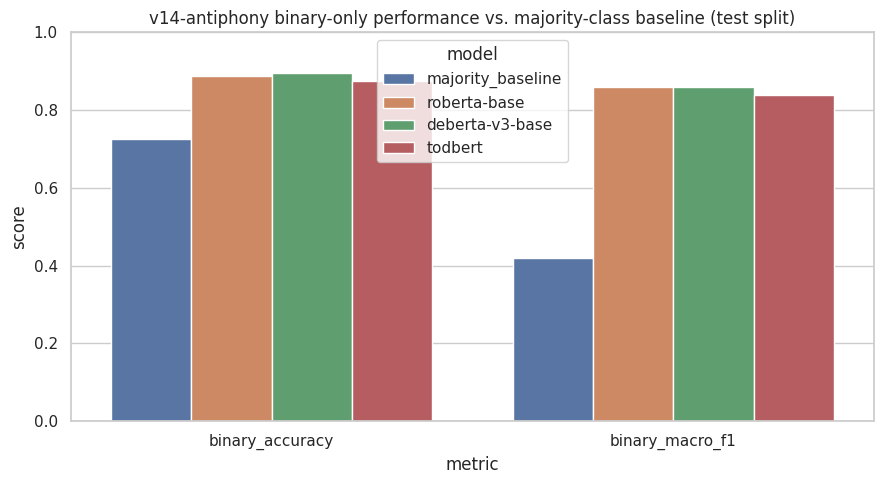

In [16]:
plot_df = summary_df.melt(
    id_vars="model",
    value_vars=["binary_accuracy", "binary_macro_f1"],
    var_name="metric", value_name="score",
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("v14-antiphony binary-only performance vs. majority-class baseline (test split)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"classifier_comparison_bar_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10b. Confusion matrices — binary_label, per encoder

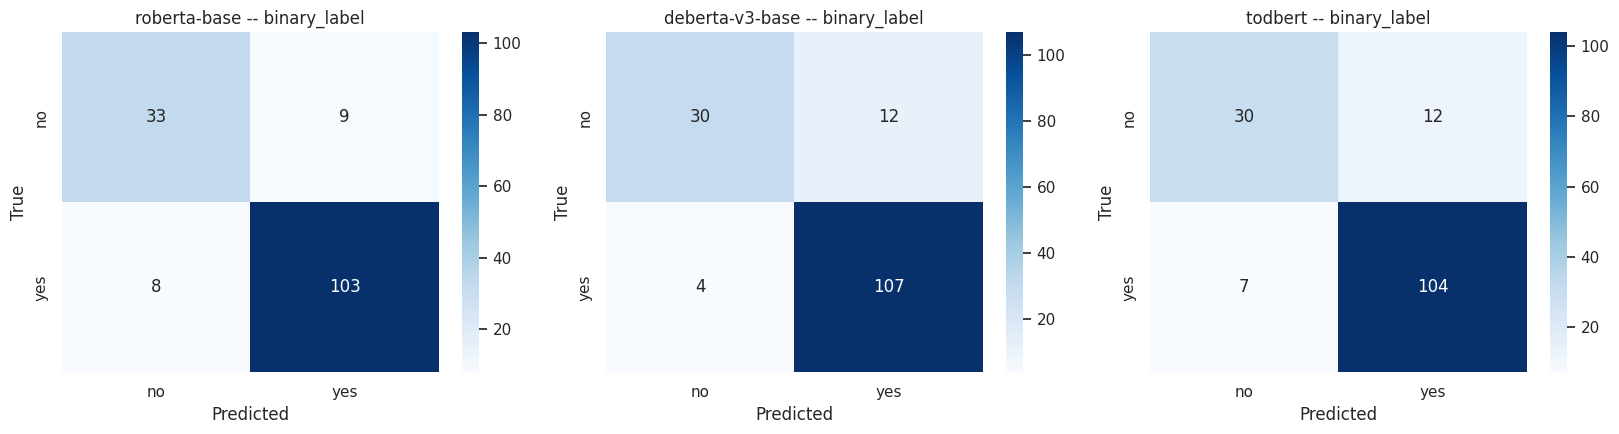

In [17]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                           labels=list(range(len(CONFIG["binary_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CONFIG["binary_classes"], yticklabels=CONFIG["binary_classes"], ax=ax)
    ax.set_title(f"{name} -- binary_label")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"confusion_matrix_binary_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10d. Training curves — val F1 per epoch, per encoder

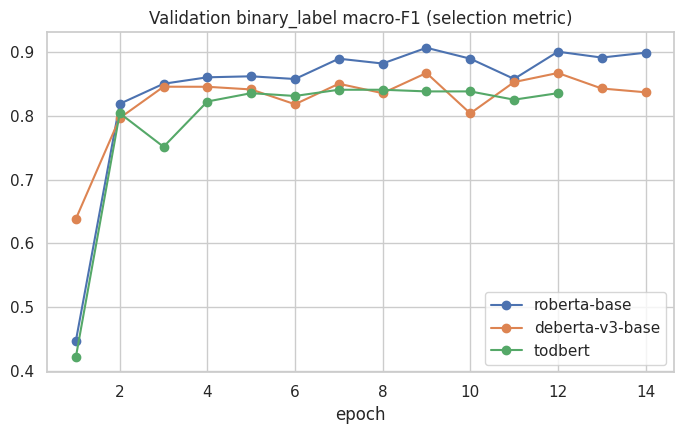

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
for name, r in results.items():
    hist = pd.DataFrame(r["history"])
    ax.plot(hist["epoch"], hist["val_binary_macro_f1"], marker="o", label=name)
ax.set_title("Validation binary_label macro-F1 (selection metric)")
ax.set_xlabel("epoch")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"training_curves_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()


## 10e. Classification reports (full precision/recall/F1 per class)

In [19]:
for name, r in results.items():
    _sep = "=" * 70
    print(f"\n{_sep}\n{name} -- binary_label classification report\n{_sep}")
    print(classification_report(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                                 target_names=CONFIG["binary_classes"], zero_division=0))



roberta-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.80      0.79      0.80        42
         yes       0.92      0.93      0.92       111

    accuracy                           0.89       153
   macro avg       0.86      0.86      0.86       153
weighted avg       0.89      0.89      0.89       153


deberta-v3-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.88      0.71      0.79        42
         yes       0.90      0.96      0.93       111

    accuracy                           0.90       153
   macro avg       0.89      0.84      0.86       153
weighted avg       0.89      0.90      0.89       153


todbert -- binary_label classification report
              precision    recall  f1-score   support

          no       0.81      0.71      0.76        42
         yes       0.90      0.94      0.92       111

    accuracy                

## 11. Summary

A new architecture, not an increment: dual-stream speaker-disentangled
encoding (separate Persuader/Persuadee Transformers) + directional
cross-attention (Persuadee queries Persuader) + a commitment-trajectory
GRU, replacing the single dialogue Transformer + attention-pool + gate
used by every prior notebook (v6-v13). Binary-only from the start, same
teacher-directed focus as v13-Solo, and built on the exact same data
pipeline, loss, and training loop as v13-Solo so the comparison is clean.

**Compare against, printed by the results cell above, not hardcoded
here:**

- v13-Solo's own per-encoder binary macro-F1 (test) — did explicit role
  disentanglement + directional cross-attention + trajectory modeling
  beat the single-sequence-plus-gating approach?
- v10-Coda's original numbers (RoBERTa 0.834, DeBERTa-v3 0.800, TOD-BERT
  0.776) and the majority-class baseline (0.4205) for the full lineage.

**What a result either way would mean:**

- If this wins, it's a genuinely different mechanism succeeding, not a
  tuned variant of something already proven — worth writing up as the
  project's actual architectural contribution.
- If it doesn't, that's still informative: it would suggest the
  project's real ceiling on this dataset is closer to a data/label-
  scarcity limit than an architecture-expressiveness one (the same
  conclusion `conditional`'s stuck-near-zero F1 has pointed at since
  v3), since a materially different, more structurally-motivated
  architecture failing to move binary performance further would be
  harder to explain away as "just needed a better encoder."
